In [1]:
import pandas as pd

event_data = pd.read_csv(
    "../data/processed/tesla_event_dataset.csv"
)

event_data.head()

,event_id,event_name,event_type,event_date,day,Date,Close,return_from_day_0,SPY_Close,SPY_return_from_day_0,abnormal_return
0,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,0,2023-01-24,143.889999,0.000000,382.664886,0.000000,0.000000
1,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,1,2023-01-25,144.429993,0.375282,382.808258,0.037467,0.337815
2,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,2,2023-01-26,160.270004,11.383699,387.015381,1.136894,10.246805
3,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,3,2023-01-27,177.899994,23.636107,387.904724,1.369302,22.266805
4,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,4,2023-01-30,166.660004,15.824591,383.037750,0.097439,15.727153


In [2]:
event_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_id               138 non-null    str    
 1   event_name             138 non-null    str    
 2   event_type             138 non-null    str    
 3   event_date             138 non-null    str    
 4   day                    138 non-null    int64  
 5   Date                   138 non-null    str    
 6   Close                  138 non-null    float64
 7   return_from_day_0      138 non-null    float64
 8   SPY_Close              138 non-null    float64
 9   SPY_return_from_day_0  138 non-null    float64
 10  abnormal_return        138 non-null    float64
dtypes: float64(5), int64(1), str(5)
memory usage: 12.0 KB


In [3]:
event_summary = event_data[event_data["day"] == 5][
    ["event_id", "event_name", "event_type", "abnormal_return"]
]

event_summary.head()

,event_id,event_name,event_type,abnormal_return
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424
11,TSLA_002,Q1 2023 Earnings,Earnings,-10.863438
17,TSLA_003,Q4 2023 Earnings,Earnings,-9.635181
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670
29,TSLA_005,Cybertruck Unveiled,Product Launch,-7.457915


In [4]:
event_summary = event_data[event_data["day"] == 5][
    ["event_id", "event_name", "event_type", "abnormal_return"]
]

event_summary.head()

,event_id,event_name,event_type,abnormal_return
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424
11,TSLA_002,Q1 2023 Earnings,Earnings,-10.863438
17,TSLA_003,Q4 2023 Earnings,Earnings,-9.635181
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670
29,TSLA_005,Cybertruck Unveiled,Product Launch,-7.457915


In [5]:
event_summary.shape

(23, 4)

In [6]:
event_summary = event_summary.sort_values(
    "abnormal_return",
    ascending=False
)

event_summary

,event_id,event_name,event_type,abnormal_return
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670
89,TSLA_015,5-for-1 Stock Split Announced,Corporate Action,28.703411
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424
65,TSLA_011,Major Price Reductions Across Key Models,Pricing Strategy,11.798452
53,TSLA_009,Global Vehicle Price Cuts,Pricing Strategy,8.251983
137,TSLA_023,Autopilot Recall Affecting Over 2 Million Vehi...,Recall,5.798085
101,TSLA_017,Shareholders Approve Elon Musk Pay Package,Corporate Action,1.372317
35,TSLA_006,Model S Plaid Delivery Event,Product Launch,0.907980
59,TSLA_010,Further US Price Cuts,Pricing Strategy,-0.831565
125,TSLA_021,Touchscreen Recall (NHTSA),Recall,-0.984186


In [7]:
event_summary["absolute_abnormal_return"] = event_summary["abnormal_return"].abs()

In [8]:
event_summary = event_summary.sort_values(
    "absolute_abnormal_return",
    ascending=False
)

event_summary 

,event_id,event_name,event_type,abnormal_return,absolute_abnormal_return
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670,34.537670
89,TSLA_015,5-for-1 Stock Split Announced,Corporate Action,28.703411,28.703411
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424,18.814424
77,TSLA_013,AI Day 2022,Technology Announcement,-14.084529,14.084529
65,TSLA_011,Major Price Reductions Across Key Models,Pricing Strategy,11.798452,11.798452
11,TSLA_002,Q1 2023 Earnings,Earnings,-10.863438,10.863438
17,TSLA_003,Q4 2023 Earnings,Earnings,-9.635181,9.635181
119,TSLA_020,Mexico Gigafactory Announced,Factory Expansion,-9.257418,9.257418
83,TSLA_014,"Robotaxi (""We, Robot"") Event",Technology Announcement,-9.074922,9.074922
95,TSLA_016,3-for-1 Stock Split Announced,Corporate Action,-8.534494,8.534494


In [9]:
import matplotlib.pyplot as plt

In [10]:
average_by_type_day = (
    event_data
    .groupby(["event_type", "day"])["abnormal_return"]
    .mean()
    .reset_index()
)

average_by_type_day.head()

,event_type,day,abnormal_return
0,Corporate Action,0,0.000000
1,Corporate Action,1,-2.009922
2,Corporate Action,2,1.190585
3,Corporate Action,3,3.680940
4,Corporate Action,4,4.302571


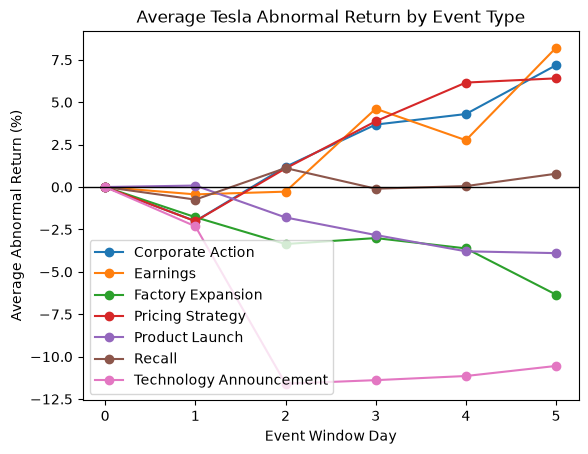

In [11]:
for event_type in average_by_type_day["event_type"].unique():

    data = average_by_type_day[
        average_by_type_day["event_type"] == event_type
    ]

    plt.plot(
        data["day"],
        data["abnormal_return"],
        marker="o",
        label=event_type
    )

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Event Window Day")
plt.ylabel("Average Abnormal Return (%)")
plt.title("Average Tesla Abnormal Return by Event Type")

plt.legend()
plt.show()

In [12]:
event_data["absolute_abnormal_return"] = event_data["abnormal_return"].abs()

In [13]:
average_magnitude_by_type_day = (
    event_data
    .groupby(["event_type", "day"])["absolute_abnormal_return"]
    .mean()
    .reset_index()
)

average_magnitude_by_type_day.head()

,event_type,day,absolute_abnormal_return
0,Corporate Action,0,0.000000
1,Corporate Action,1,3.823544
2,Corporate Action,2,4.934117
3,Corporate Action,3,8.691967
4,Corporate Action,4,8.323230


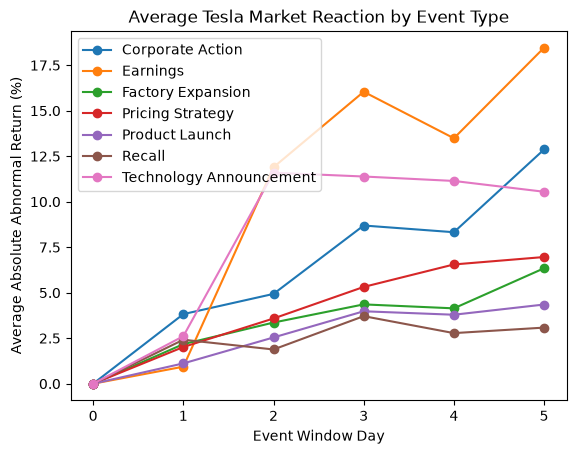

In [14]:
for event_type in average_magnitude_by_type_day["event_type"].unique():

    data = average_magnitude_by_type_day[
        average_magnitude_by_type_day["event_type"] == event_type
    ]

    plt.plot(
        data["day"],
        data["absolute_abnormal_return"],
        marker="o",
        label=event_type
    )

plt.xlabel("Event Window Day")
plt.ylabel("Average Absolute Abnormal Return (%)")
plt.title("Average Tesla Market Reaction by Event Type")

plt.legend()
plt.show()

“Technology Announcement events exhibited consistently negative abnormal returns in the Tesla sample. Contemporary reporting suggests these events were generally highly anticipated, with negative reactions driven partly by announcements failing to meet elevated investor expectations, uncertain commercial timelines and limited near-term financial detail.”

In [15]:
category_impact = (
    event_summary
    .groupby("event_type")["absolute_abnormal_return"]
    .mean()
    .sort_values(ascending=False)
)

category_impact

event_type
Earnings                   18.462678
Corporate Action           12.870074
Technology Announcement    10.546866
Pricing Strategy            6.960666
Factory Expansion           6.343328
Product Launch              4.350571
Recall                      3.081760
Name: absolute_abnormal_return, dtype: float64

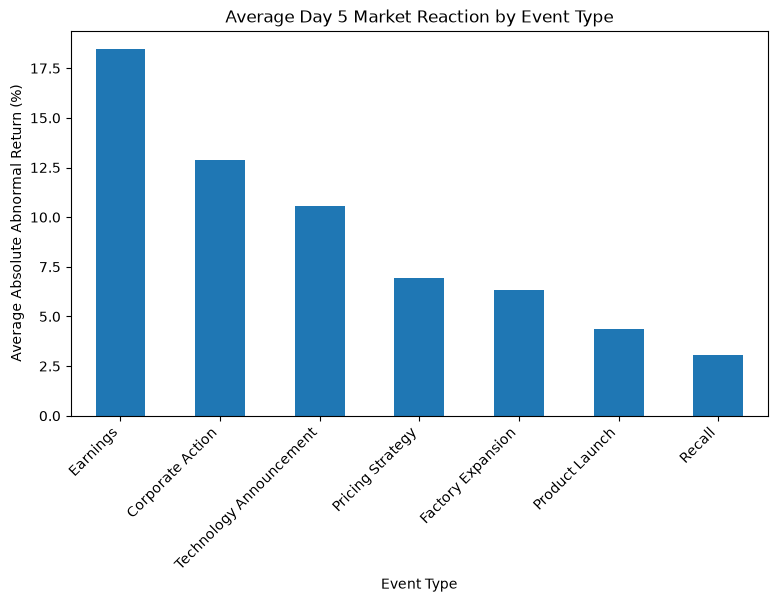

In [16]:
category_impact.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Event Type")
plt.ylabel("Average Absolute Abnormal Return (%)")
plt.title("Average Day 5 Market Reaction by Event Type")

plt.xticks(rotation=45, ha="right")
plt.show()

In [17]:
category_stats = (
    event_summary
    .groupby("event_type")["absolute_abnormal_return"]
    .agg(["mean", "median"])
    .sort_values("mean", ascending=False)
)

category_stats

,mean,median
event_type,,
Earnings,18.462678,14.838931
Corporate Action,12.870074,8.534494
Technology Announcement,10.546866,9.074922
Pricing Strategy,6.960666,8.251983
Factory Expansion,6.343328,8.254801
Product Launch,4.350571,4.518194
Recall,3.081760,2.463008


Earnings produced the largest reaction magnitudes in the Tesla sample, while Technology Announcements also showed consistently large reactions. Corporate Actions had a high average reaction, but this was influenced considerably by the 5-for-1 stock split event. Product Launches and Recalls generally produced smaller reactions.

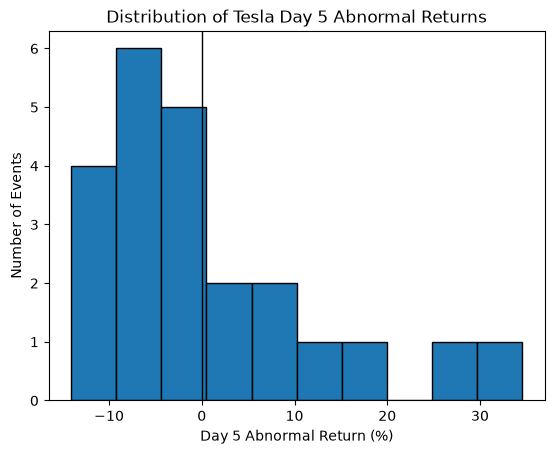

In [18]:
plt.hist(
    event_summary["abnormal_return"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("Day 5 Abnormal Return (%)")
plt.ylabel("Number of Events")
plt.title("Distribution of Tesla Day 5 Abnormal Returns")

plt.axvline(0, color="black", linewidth=1)

plt.show()

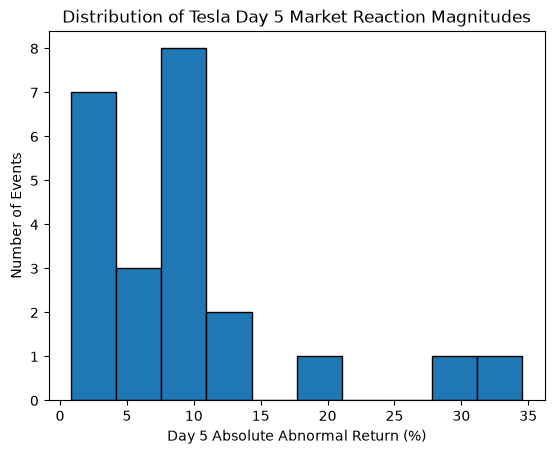

In [19]:
plt.hist(
    event_summary["absolute_abnormal_return"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("Day 5 Absolute Abnormal Return (%)")
plt.ylabel("Number of Events")
plt.title("Distribution of Tesla Day 5 Market Reaction Magnitudes")

plt.show()

individual event trajectories, because that will let you see whether some events spike immediately, build gradually, or reverse over the Day 0–Day 5 window.

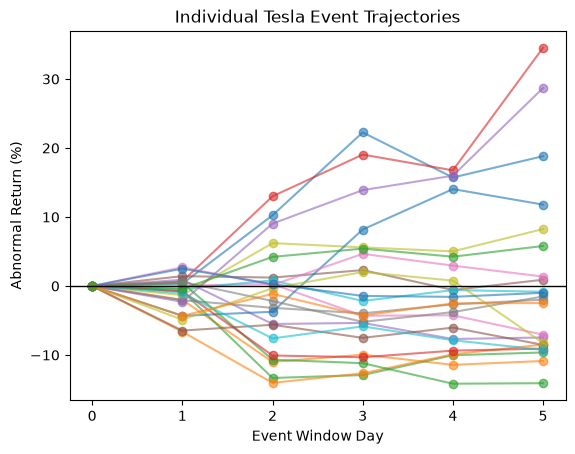

In [20]:
for event_id in event_data["event_id"].unique():

    data = event_data[
        event_data["event_id"] == event_id
    ]

    plt.plot(
        data["day"],
        data["abnormal_return"],
        marker="o",
        alpha=0.6
    )

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Event Window Day")
plt.ylabel("Abnormal Return (%)")
plt.title("Individual Tesla Event Trajectories")

plt.show()

In [21]:
top_5_ids = (
    event_summary
    .nlargest(5, "absolute_abnormal_return")["event_id"]
)

top_5_ids

23    TSLA_004
89    TSLA_015
5     TSLA_001
77    TSLA_013
65    TSLA_011
Name: event_id, dtype: str

In [22]:
top_5_data = event_data[
    event_data["event_id"].isin(top_5_ids)
]

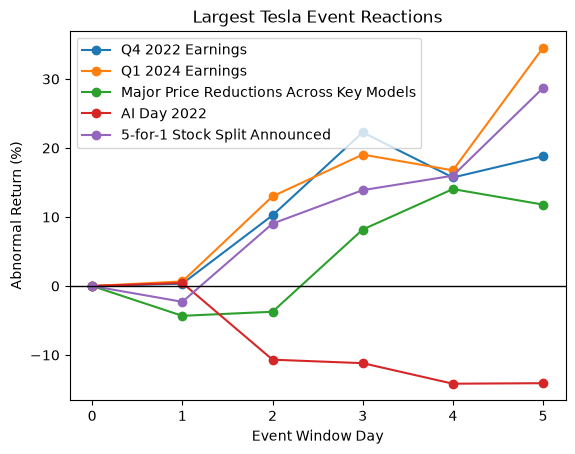

In [23]:
for event_id in top_5_data["event_id"].unique():

    data = top_5_data[
        top_5_data["event_id"] == event_id
    ]

    event_name = data["event_name"].iloc[0]

    plt.plot(
        data["day"],
        data["abnormal_return"],
        marker="o",
        label=event_name
    )

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Event Window Day")
plt.ylabel("Abnormal Return (%)")
plt.title("Largest Tesla Event Reactions")

plt.legend()
plt.show()

“The largest Tesla event reactions often accumulated over several trading days rather than occurring entirely on the first trading day. Reaction trajectories also differed across events, with some showing gradual repricing and others showing early spikes followed by persistence or partial reversal.”